In [164]:
import pandas as pd
import matplotlib.pyplot as plt

pm25_df = pd.read_csv("../data_final/Table2_1b.csv",header=2)
who_df = pd.read_csv("../data_final/b7450f71-eae9-4c95-98e4-022ddec4a93f.csv")
emissions_df = pd.read_csv("../data_final/fig03_particulate_matter_annual_emissions.csv")

print(pm25_df.head())
print(who_df.head())
print(emissions_df.head())

   Year              Site  Annual Mean PM2.5 concentration (µg/m3)[note 1]  \
0  2009  All sites (mean)                                        12.393308   
1  2010  All sites (mean)                                        12.973033   
2  2011  All sites (mean)                                        13.704840   
3  2012  All sites (mean)                                        12.561473   
4  2013  All sites (mean)                                        12.087197   

  95% confidence interval for 'All sites' (+/-)[note 3] Data capture (%)  \
0                                  0.626062170751266                 [z]   
1                                  0.812720694156802                 [z]   
2                                  0.893151641790071                 [z]   
3                                  0.768436234500607                 [z]   
4                                  0.675479966840495                 [z]   

  Measurement Frequency[note 4]  
0                           [z]  
1     

In [165]:
import hashlib

def get_hash(path):
    with open(path, "rb") as f:
        return hashlib.sha256(f.read()).hexdigest()

print(get_hash("../data_final/Table2_1b.csv"))
print(get_hash("../data_final/b7450f71-eae9-4c95-98e4-022ddec4a93f.csv"))
print(get_hash("../data_final/fig03_particulate_matter_annual_emissions.csv"))

91bb9a120363c63607e85a5b7239e5c19734544477901f2b08ace08cc5473e63
547fc92212ae6e3e8f04f80e0e8b25bbf92a2892fa12e990786fe6344639443c
1078586776fba72123f23bd0c6723ad8befb63ef7132c23497bca7fd44db2bbf


In [166]:
print("PM25")
print(pm25_df.head())
print(pm25_df.columns)
print(pm25_df.shape)
print(pm25_df.isna().sum())

print("\nWHO")
print(who_df.head())
print(who_df.columns)
print(who_df.shape)
print(who_df.isna().sum())

print("\nEMISSIONS")
print(emissions_df.head())
print(emissions_df.columns)
print(emissions_df.shape)
print(emissions_df.isna().sum())

PM25
   Year              Site  Annual Mean PM2.5 concentration (µg/m3)[note 1]  \
0  2009  All sites (mean)                                        12.393308   
1  2010  All sites (mean)                                        12.973033   
2  2011  All sites (mean)                                        13.704840   
3  2012  All sites (mean)                                        12.561473   
4  2013  All sites (mean)                                        12.087197   

  95% confidence interval for 'All sites' (+/-)[note 3] Data capture (%)  \
0                                  0.626062170751266                 [z]   
1                                  0.812720694156802                 [z]   
2                                  0.893151641790071                 [z]   
3                                  0.768436234500607                 [z]   
4                                  0.675479966840495                 [z]   

  Measurement Frequency[note 4]  
0                           [z]  
1

In [167]:
pm25_clean = pm25_df.iloc[:, [0, 1, 2]].copy()
pm25_clean.columns = ["year", "site", "pm25_concentration"]

pm25_clean["year"] = pd.to_numeric(pm25_clean["year"], errors="coerce")
pm25_clean["pm25_concentration"] = pd.to_numeric(pm25_clean["pm25_concentration"], errors="coerce")

pm25_clean = pm25_clean.dropna(subset=["year", "pm25_concentration"])
pm25_clean["year"] = pm25_clean["year"].astype(int)

pm25_clean.head()

,year,site,pm25_concentration
0,2009,All sites (mean),12.393308
1,2010,All sites (mean),12.973033
2,2011,All sites (mean),13.704840
3,2012,All sites (mean),12.561473
4,2013,All sites (mean),12.087197


In [168]:
who_clean = who_df[["Period", "Location", "Indicator", "FactValueNumeric", "Dim1", "Dim2"]].copy()
who_clean.columns = ["year", "location", "indicator", "mortality_value", "sex", "cause"]

who_clean["year"] = pd.to_numeric(who_clean["year"], errors="coerce")
who_clean["mortality_value"] = pd.to_numeric(who_clean["mortality_value"], errors="coerce")

who_clean = who_clean.dropna(subset=["year", "mortality_value"])
who_clean["year"] = who_clean["year"].astype(int)

who_clean.head()

,year,location,indicator,mortality_value,sex,cause
0,2019,United Kingdom of Great Britain and Northern I...,Ambient air pollution attributable deaths,10361.0,Female,All causes
1,2019,United Kingdom of Great Britain and Northern I...,Ambient air pollution attributable deaths,11234.0,Both sexes,Ischaemic heart disease
2,2019,United Kingdom of Great Britain and Northern I...,Ambient air pollution attributable deaths,11972.0,Male,All causes
3,2019,United Kingdom of Great Britain and Northern I...,Ambient air pollution attributable deaths,1208.0,Female,Chronic obstructive pulmonary disease
4,2019,United Kingdom of Great Britain and Northern I...,Ambient air pollution attributable deaths,1286.0,Male,Chronic obstructive pulmonary disease


In [169]:
emissions_clean = emissions_df.copy()
emissions_clean.columns = ["pollutant", "year", "emissions_thousand_tonnes"]

emissions_clean["year"] = pd.to_numeric(emissions_clean["year"], errors="coerce")
emissions_clean["emissions_thousand_tonnes"] = pd.to_numeric(
    emissions_clean["emissions_thousand_tonnes"], errors="coerce"
)

emissions_clean = emissions_clean.dropna(subset=["year", "emissions_thousand_tonnes"])
emissions_clean["year"] = emissions_clean["year"].astype(int)

emissions_clean = emissions_clean[emissions_clean["pollutant"] == "PM2.5"].copy()

emissions_clean.head()

,pollutant,year,emissions_thousand_tonnes
55,PM2.5,1970,545.786787
56,PM2.5,1971,483.834732
57,PM2.5,1972,424.825260
58,PM2.5,1973,432.199186
59,PM2.5,1974,400.967193


In [170]:
emissions_yearwise = emissions_df.copy()
emissions_yearwise.columns = ["pollutant", "year", "emissions_thousand_tonnes"]

emissions_yearwise["year"] = pd.to_numeric(emissions_yearwise["year"], errors="coerce")
emissions_yearwise["emissions_thousand_tonnes"] = pd.to_numeric(
    emissions_yearwise["emissions_thousand_tonnes"], errors="coerce"
)

emissions_yearwise = emissions_yearwise.dropna(subset=["year", "emissions_thousand_tonnes"])
emissions_yearwise["year"] = emissions_yearwise["year"].astype(int)

emissions_yearwise = emissions_yearwise[
    emissions_yearwise["pollutant"].isin(["PM2.5", "PM10"])
].copy()

emissions_yearwise = emissions_yearwise.pivot(
    index="year",
    columns="pollutant",
    values="emissions_thousand_tonnes"
).reset_index()

emissions_yearwise.columns.name = None
emissions_yearwise = emissions_yearwise.rename(columns={
    "PM2.5": "pm25_emissions",
    "PM10": "pm10_emissions"
})

print(emissions_yearwise.shape)
print(emissions_yearwise.isna().sum())
print(emissions_yearwise.head())

(55, 3)
year              0
pm10_emissions    0
pm25_emissions    0
dtype: int64
   year  pm10_emissions  pm25_emissions
0  1970      689.444181      545.786787
1  1971      634.162134      483.834732
2  1972      560.969478      424.825260
3  1973      584.853938      432.199186
4  1974      531.686350      400.967193


In [171]:
emissions_yearwise.to_csv("../data_final/emissions_yearwise.csv", index=False)
print("Saved to ../data_final/emissions_yearwise.csv")

Saved to ../data_final/emissions_yearwise.csv


In [172]:
print(who_df[["Dim1", "Dim2", "FactValueNumeric"]].drop_duplicates().sort_values(["Dim1", "Dim2"]).head(30))

print(who_df["Dim1"].dropna().unique()[:20])
print(who_df["Dim2"].dropna().unique()[:20])
print(who_df["Location"].dropna().unique()[:20])

print(pm25_clean["site"].dropna().unique()[:20])
print(emissions_clean["pollutant"].dropna().unique())

           Dim1                                   Dim2  FactValueNumeric
13   Both sexes     Acute lower respiratory infections            4085.0
31   Both sexes     Acute lower respiratory infections            4260.0
49   Both sexes     Acute lower respiratory infections            4166.0
67   Both sexes     Acute lower respiratory infections            4031.0
85   Both sexes     Acute lower respiratory infections            4749.0
103  Both sexes     Acute lower respiratory infections            4006.0
122  Both sexes     Acute lower respiratory infections            4252.0
139  Both sexes     Acute lower respiratory infections            4240.0
157  Both sexes     Acute lower respiratory infections            4474.0
175  Both sexes     Acute lower respiratory infections            4502.0
9    Both sexes                             All causes           22333.0
27   Both sexes                             All causes           23717.0
46   Both sexes                             All cau

In [173]:
pm25_uk = pm25_clean[pm25_clean["site"] == "All sites (mean)"].copy()

who_uk = who_clean[
    (who_clean["location"] == "United Kingdom of Great Britain and Northern Ireland") &
    (who_clean["sex"] == "Both sexes") &
    (who_clean["cause"] == "All causes")
].copy()

emissions_pm25 = emissions_clean.copy()

In [174]:
pm25_uk["geography"] = "United Kingdom"
who_uk["geography"] = "United Kingdom"
emissions_pm25["geography"] = "United Kingdom"

pm25_uk = pm25_uk[["year", "geography", "pm25_concentration"]]
who_uk = who_uk[["year", "geography", "mortality_value"]]
emissions_pm25 = emissions_pm25[["year", "geography", "emissions_thousand_tonnes"]]

In [175]:
print(pm25_uk.head())
print(who_uk.head())
print(emissions_pm25.head())
print(emissions_yearwise.head())

   year       geography  pm25_concentration
0  2009  United Kingdom           12.393308
1  2010  United Kingdom           12.973033
2  2011  United Kingdom           13.704840
3  2012  United Kingdom           12.561473
4  2013  United Kingdom           12.087197
    year       geography  mortality_value
9   2019  United Kingdom          22333.0
27  2018  United Kingdom          23717.0
46  2017  United Kingdom          24077.0
64  2016  United Kingdom          24489.0
81  2015  United Kingdom          27252.0
    year       geography  emissions_thousand_tonnes
55  1970  United Kingdom                 545.786787
56  1971  United Kingdom                 483.834732
57  1972  United Kingdom                 424.825260
58  1973  United Kingdom                 432.199186
59  1974  United Kingdom                 400.967193
   year  pm10_emissions  pm25_emissions
0  1970      689.444181      545.786787
1  1971      634.162134      483.834732
2  1972      560.969478      424.825260
3  1973     

In [176]:
print(sorted(pm25_uk["year"].unique()))
print(sorted(who_uk["year"].unique()))
print(sorted(emissions_pm25["year"].unique()))

[2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
[2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019]
[1970, 1971, 1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979, 1980, 1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]


In [177]:
integrated_master_df = pm25_uk.merge(
    emissions_pm25,
    on=["year", "geography"],
    how="outer"
).merge(
    who_uk,
    on=["year", "geography"],
    how="outer"
).sort_values("year").reset_index(drop=True)

integrated_master_df.head()

,year,geography,pm25_concentration,emissions_thousand_tonnes,mortality_value
0,1970,United Kingdom,NaN,545.786787,NaN
1,1971,United Kingdom,NaN,483.834732,NaN
2,1972,United Kingdom,NaN,424.825260,NaN
3,1973,United Kingdom,NaN,432.199186,NaN
4,1974,United Kingdom,NaN,400.967193,NaN


In [178]:
integrated_master_df.to_csv("../data_final/final_data.csv", index=False)
pm25_uk.to_csv("../data_final/pm25_uk.csv", index=False)
who_uk.to_csv("../data_final/who_uk.csv", index=False)
emissions_pm25.to_csv("../data_final/emissions.csv", index=False)

print("Saved all cleaned and integrated files to /Users/suryachhabra/Desktop/IS_477_Group_Project/data_final/")

Saved all cleaned and integrated files to /Users/suryachhabra/Desktop/IS_477_Group_Project/data_final/


In [179]:
print(pm25_clean.duplicated().sum())
print(who_clean.duplicated().sum())
print(emissions_clean.duplicated().sum())
print(emissions_yearwise.duplicated().sum())

0
0
0
0


In [180]:
#How has all-cause mortality changed over time in the UK?
who_uk = who_clean[
    (who_clean["location"] == "United Kingdom of Great Britain and Northern Ireland")
].copy() #Creates a copy of the cleaned dataset, with location set to UK

who_uk = who_uk.sort_values("year") #Sorts values by year

who_by_year = (
    who_uk
    .groupby("year")["mortality_value"]
    .mean()
    .reset_index()
) #Groupby year and find the mean mortality value for each year (This is dataset only has 2010-2019)

who_by_year

,year,mortality_value
0,2010,7067.850000
1,2011,6622.716667
2,2012,6393.000000
3,2013,6311.405556
4,2014,5746.188889
5,2015,6055.966667
6,2016,5442.044444
7,2017,5350.500000
8,2018,5270.433333
9,2019,4962.916667


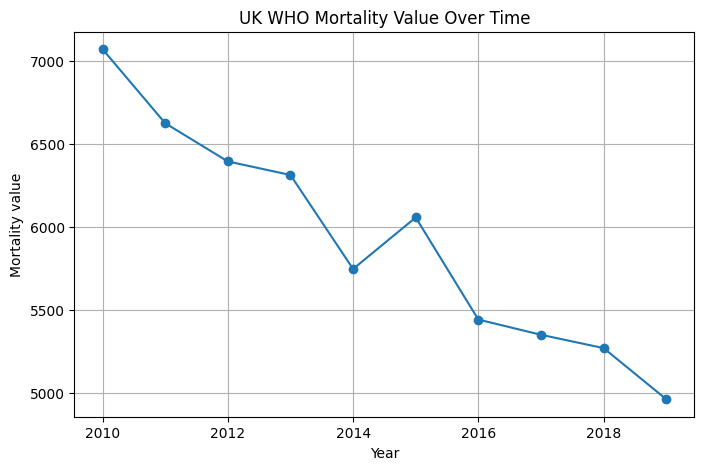

In [181]:
plt.figure(figsize=(8, 5))
plt.plot(who_by_year["year"], who_by_year["mortality_value"], marker="o")
plt.title("UK WHO Mortality Value Over Time")
plt.xlabel("Year")
plt.ylabel("Mortality value")
plt.grid(True)
plt.show()

In [182]:
emissions_without_extra = emissions_clean[
    emissions_clean["pollutant"].isin(["PM10", "PM2.5"])
].copy() 
#Copys clean emission data, excludes the extra rows containing "erc_2020-2029", 
#this was a single value repeated for each year. My best guess is that it is a placeholder for 2020-2029 and not actually observed emissions

emissions_2010_2019 = emissions_without_extra[
    (emissions_clean["year"] >= 2010) &
    (emissions_clean["year"] <= 2019)
].copy() #Only filtered to 2019 to keep in line with the WHO data and avoid this extra placeholder

emissions_2010_2019.head()

emissions_by_year = (
    emissions_2010_2019
    .groupby("year")["emissions_thousand_tonnes"]
    .sum()
    .reset_index()
) #Groupby year for graphing

emissions_by_year.head(20)

,year,emissions_thousand_tonnes
0,2010,79.993241
1,2011,76.145328
2,2012,75.935942
3,2013,75.844929
4,2014,72.918708
5,2015,71.329266
6,2016,68.324910
7,2017,68.493139
8,2018,68.686810
9,2019,65.258334


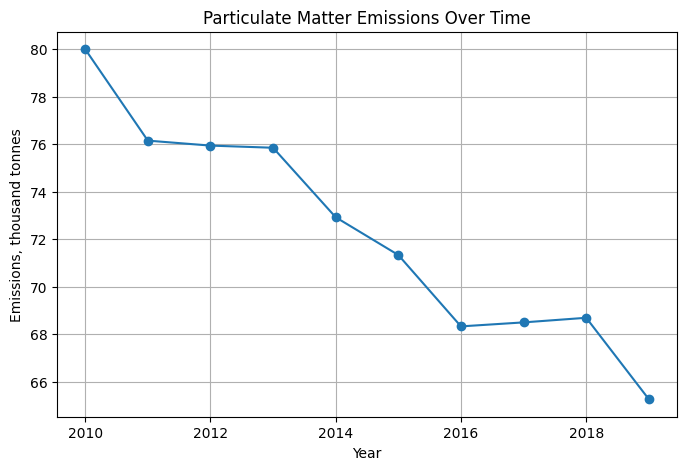

In [183]:
plt.figure(figsize=(8, 5))
plt.plot(
    emissions_by_year["year"],
    emissions_by_year["emissions_thousand_tonnes"],
    marker="o"
)

plt.title("Particulate Matter Emissions Over Time")
plt.xlabel("Year")
plt.ylabel("Emissions, thousand tonnes")
plt.grid(True)
plt.show()

In [184]:
#Copys clean emission data, excludes the extra rows containing "erc_2020-2029", 
#this was a single value repeated for each year. My best guess is that it is a placeholder for 2020-2029 and not actually observed emissions

pm25_concentration_2010_2019 = pm25_uk[
    (pm25_uk["year"] >= 2010) &
    (pm25_uk["year"] <= 2019)
].copy() #Only filtered to 2019 to keep in line with the WHO data and avoid this extra placeholder

pm25_concentration_2010_2019.head()

concentrations_by_year = (
    pm25_concentration_2010_2019
    .groupby("year")["pm25_concentration"]
    .sum()
    .reset_index()
) #Groupby year for graphing

concentrations_by_year.head(20)

,year,pm25_concentration
0,2010,12.973033
1,2011,13.704840
2,2012,12.561473
3,2013,12.087197
4,2014,12.079755
5,2015,9.771606
6,2016,9.789564
7,2017,9.414699
8,2018,9.925692
9,2019,9.880706


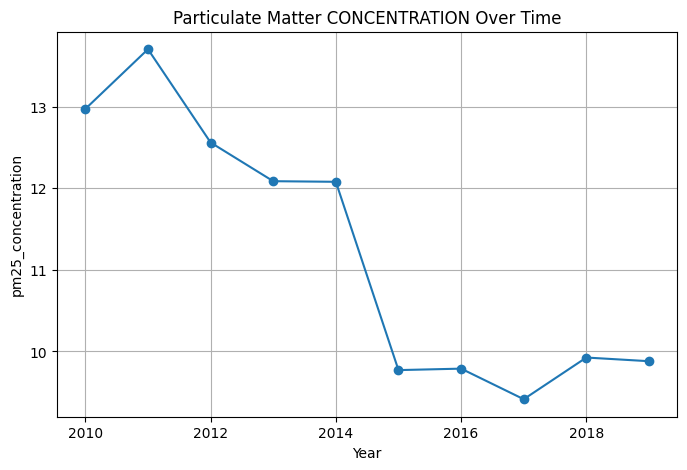

In [185]:
plt.figure(figsize=(8, 5))
plt.plot(
    concentrations_by_year["year"],
    concentrations_by_year["pm25_concentration"],
    marker="o"
)

plt.title("Particulate Matter CONCENTRATION Over Time")
plt.xlabel("Year")
plt.ylabel("pm25_concentration")
plt.grid(True)
plt.show()

In [186]:
pm25_emissions_concentration = pm25_uk.merge(
    emissions_pm25,
    on="year",
    how="inner"
)#Combining emissions and concentration datasets

In [187]:
pm25_emissions_concentration[
    ["pm25_concentration", "emissions_thousand_tonnes"]
].corr() #Correlation between concentration and emissions

,pm25_concentration,emissions_thousand_tonnes
pm25_concentration,1.00000,0.95106
emissions_thousand_tonnes,0.95106,1.00000


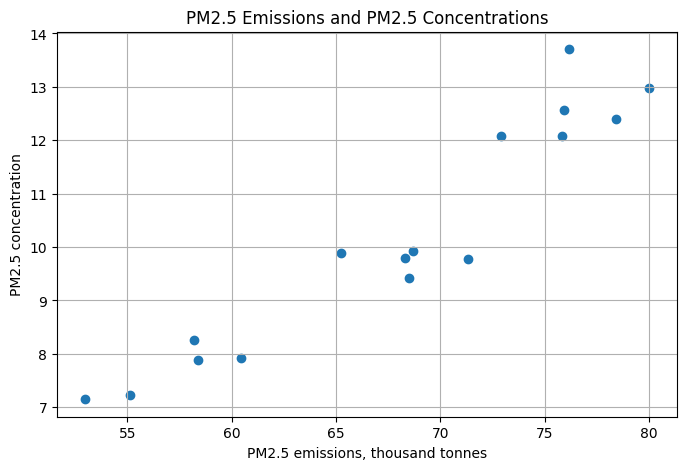

In [188]:
plt.figure(figsize=(8, 5))
plt.scatter(
    pm25_emissions_concentration["emissions_thousand_tonnes"],
    pm25_emissions_concentration["pm25_concentration"]
)

plt.title("PM2.5 Emissions and PM2.5 Concentrations")
plt.xlabel("PM2.5 emissions, thousand tonnes")
plt.ylabel("PM2.5 concentration")
plt.grid(True)
plt.show()